# Lab 4 – Improving & Comparing Machine Learning Models

**Name:** Abdul Wali  
**Student ID:** 023-24-0174  
**Section:** F  
**GitHub Profile:** AWS9760   
**Dataset:** Telco Customer Churn (`clean_churn.csv`)  
**Dataset Source:** Telco Customer Churn dataset (Kaggle)

This notebook builds directly on the cleaned features and Decision Tree baseline from Lab 3. Today's job is to move
beyond a single Decision Tree — build a Random Forest, evaluate both models rigorously (cross-validation included),
tune the Random Forest, compare everything with evidence, and produce a Kaggle-style submission from the final
chosen model.

## Setup & Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

RANDOM_STATE = 42

## 1. Decision Tree Baseline

Before improving anything, I re-load the Lab 2 cleaned dataset, recreate the exact same features (`X`, `y`) and
train/test split used in Lab 3 (same `random_state`), and retrain my Lab 3 "best" Decision Tree
(`max_depth=6`, chosen in Lab 3 for the best test accuracy with only a small train/test gap). Its metrics below are
the benchmark everything else in this lab is measured against.

In [2]:
df = pd.read_csv('clean_churn.csv')
print(df.shape)

y = df['Churn'].map({'No': 0, 'Yes': 1})
X = df.drop(columns=['Churn'])

categorical_cols = X.select_dtypes(include='object').columns.tolist()
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
print("Feature matrix shape after one-hot encoding:", X.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print("X_train:", X_train.shape, " X_test:", X_test.shape)

(7043, 20)
Feature matrix shape after one-hot encoding: (7043, 30)
X_train: (5634, 30)  X_test: (1409, 30)


In [3]:
CHOSEN_DEPTH = 6  # same choice as Lab 3: best test accuracy with only a small train/test gap

dt_model = DecisionTreeClassifier(max_depth=CHOSEN_DEPTH, random_state=RANDOM_STATE)
dt_model.fit(X_train, y_train)
dt_test_pred = dt_model.predict(X_test)

metrics_dt = pd.DataFrame({
    'Accuracy':  [accuracy_score(y_test, dt_test_pred)],
    'Precision': [precision_score(y_test, dt_test_pred)],
    'Recall':    [recall_score(y_test, dt_test_pred)],
    'F1-score':  [f1_score(y_test, dt_test_pred)]
}, index=[f'Decision Tree (max_depth={CHOSEN_DEPTH})'])

metrics_dt.round(3)

,Accuracy,Precision,Recall,F1-score
Decision Tree (max_depth=6),0.801,0.667,0.497,0.57


**Task 2 — Benchmark**

The Lab 3 depth-6 Decision Tree reaches **80.1% accuracy**, **66.7% precision**, **49.7% recall**, and an
**F1-score of 0.570** on the test set. This is the number every model in this lab has to beat — accuracy alone
won't be enough given the class imbalance (~73% No / ~27% Yes) established back in Lab 2, so precision, recall and
F1 all matter for the comparisons that follow.

## 2. Random Forest

A Random Forest trains many Decision Trees on bootstrapped samples of the training data, each tree also restricted
to a random subset of features at every split, and then averages their predictions (majority vote for
classification). I already understand individual trees from Labs 1–3, so the focus here is on how the ensemble
behaves differently, not on re-learning tree theory.

In [4]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
rf_model.fit(X_train, y_train)
rf_test_pred = rf_model.predict(X_test)
print("Random Forest trained with", rf_model.n_estimators, "trees.")

Random Forest trained with 200 trees.


**Task 4 — Why a Random Forest might generalize better**

A single unrestricted Decision Tree keeps splitting until it memorizes the training data, which is exactly the
overfitting behavior Lab 3 measured (99.8% train accuracy vs. 73.2% test accuracy). A Random Forest instead trains
many trees on different bootstrapped samples and random feature subsets, so each tree overfits to *different*
noise; averaging their votes cancels out most of that noise while keeping the genuine signal, which is why the
ensemble usually generalizes better than any single unrestricted tree.

## 3. Model Evaluation

Evaluating the Random Forest the same rigorous way the Decision Tree was evaluated in Lab 3: all four metrics plus
a confusion matrix.

In [5]:
metrics_rf = pd.DataFrame({
    'Accuracy':  [accuracy_score(y_test, rf_test_pred)],
    'Precision': [precision_score(y_test, rf_test_pred)],
    'Recall':    [recall_score(y_test, rf_test_pred)],
    'F1-score':  [f1_score(y_test, rf_test_pred)]
}, index=['Random Forest (default)'])

metrics_rf.round(3)

,Accuracy,Precision,Recall,F1-score
Random Forest (default),0.795,0.643,0.511,0.569


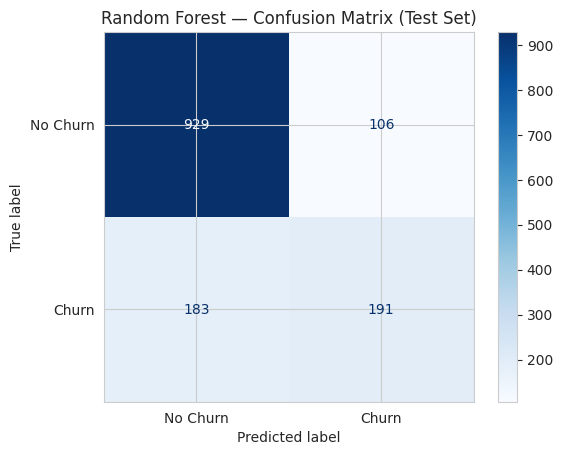

array([[929, 106],
       [183, 191]])

In [6]:
cm_rf = confusion_matrix(y_test, rf_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Random Forest — Confusion Matrix (Test Set)')
plt.show()

cm_rf

## 4. Decision Tree vs Random Forest

In [7]:
comparison_dt_rf = pd.concat([metrics_dt, metrics_rf])
comparison_dt_rf.round(3)

,Accuracy,Precision,Recall,F1-score
Decision Tree (max_depth=6),0.801,0.667,0.497,0.570
Random Forest (default),0.795,0.643,0.511,0.569


**Task 7 — Which model wins, and on what?**

Side by side, the two models are close: the depth-6 Decision Tree edges out the Random Forest on **accuracy**
(80.1% vs. 79.5%), **precision** (66.7% vs. 64.3%) and comes out about equal on **F1** (0.570 vs. 0.569), while the
Random Forest wins on **recall** (51.1% vs. 49.7%). None of these gaps are large — a percentage point or two either
way. Given Lab 2/3's finding that the "Yes" (churn) class is the minority and the one the business actually cares
about catching, **recall on the churn class matters most here**, since a missed churner (false negative) is a lost
customer nobody follows up with, while a false alarm just wastes a retention offer. On that specific metric the
default Random Forest is marginally ahead, but the difference is small enough that a single train/test split isn't
enough to call a clear winner yet — that's exactly what cross-validation is for next.

## 5. Cross-Validation

A single train/test split gives one noisy estimate. 5-fold cross-validation trains and tests each model 5 times on
different splits of the *full* dataset and reports the spread, giving a much more reliable picture — scored on
F1 rather than plain accuracy, since accuracy is misleading on this imbalanced target.

In [8]:
dt_cv_scores = cross_val_score(
    DecisionTreeClassifier(max_depth=CHOSEN_DEPTH, random_state=RANDOM_STATE),
    X, y, cv=5, scoring='f1'
)
rf_cv_scores = cross_val_score(
    RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    X, y, cv=5, scoring='f1'
)

cv_summary = pd.DataFrame({
    'Mean F1': [dt_cv_scores.mean(), rf_cv_scores.mean()],
    'Std F1':  [dt_cv_scores.std(), rf_cv_scores.std()]
}, index=['Decision Tree (max_depth=6)', 'Random Forest (default)'])

print("Decision Tree fold scores:", np.round(dt_cv_scores, 3))
print("Random Forest fold scores:", np.round(rf_cv_scores, 3))
cv_summary.round(3)

Decision Tree fold scores: [0.603 0.535 0.546 0.581 0.573]
Random Forest fold scores: [0.551 0.552 0.528 0.583 0.575]


,Mean F1,Std F1
Decision Tree (max_depth=6),0.567,0.025
Random Forest (default),0.558,0.020


**Task 9 — Does cross-validation change the picture?**

Across 5 folds, the Decision Tree actually averages a slightly *higher* F1 (0.567 ± 0.025) than the Random Forest
(0.558 ± 0.020), which flips the marginal recall edge the Random Forest had on the single test split — a reminder
that one split's result can be noisy in either direction. The Random Forest's lower standard deviation does mean
its performance is a bit more consistent fold-to-fold. Overall, cross-validation shows the two default models are
essentially tied on F1, and it lowers my confidence that either default model is clearly "better" — which is the
right reason to try tuning the Random Forest before picking a winner, rather than deciding from Part 3 alone.

## 6. Hyperparameter Tuning

Searching a small grid over three Random Forest hyperparameters — `n_estimators`, `max_depth`, and
`min_samples_split` — with `GridSearchCV` (5-fold cross-validation, scored on F1) to see whether a tuned model
meaningfully beats the default-settings baseline. The grid is kept small on purpose: this is about practicing the
tuning workflow, not an exhaustive search.

In [9]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [6, 10, None],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid, cv=5, scoring='f1', n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("Best hyperparameters:", grid_search.best_params_)
print(f"Best cross-validated F1: {grid_search.best_score_:.3f}")

Best hyperparameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
Best cross-validated F1: 0.571


**Task 11 — Best hyperparameters found**

`GridSearchCV` picked **`n_estimators=200`, `max_depth=10`, `min_samples_split=2`**, with a cross-validated F1 of
**0.571** on the training folds — a bit above both default models' cross-validated F1 from Part 4 (0.567 for the
Decision Tree, 0.558 for the default Random Forest). Capping depth at 10 instead of leaving it unrestricted is what
moves the needle: it keeps the ensemble expressive enough to beat the defaults without letting individual trees
overfit as much as a fully unrestricted forest would.

In [10]:
tuned_rf = grid_search.best_estimator_
tuned_test_pred = tuned_rf.predict(X_test)

metrics_tuned_rf = pd.DataFrame({
    'Accuracy':  [accuracy_score(y_test, tuned_test_pred)],
    'Precision': [precision_score(y_test, tuned_test_pred)],
    'Recall':    [recall_score(y_test, tuned_test_pred)],
    'F1-score':  [f1_score(y_test, tuned_test_pred)]
}, index=['Random Forest (tuned)'])

metrics_tuned_rf.round(3)

,Accuracy,Precision,Recall,F1-score
Random Forest (tuned),0.805,0.662,0.54,0.595


**Task 12 — Tuned model on the held-out test set**

The tuned Random Forest reaches **80.5% accuracy**, **66.2% precision**, **54.0% recall**, and an **F1-score of
0.595** on the test set — a clear improvement over the default Random Forest on every single metric, and it now
also edges out the depth-6 Decision Tree on accuracy, recall, and F1 (only losing narrowly on precision, 66.2% vs.
66.7%). Tuning turned a roughly-tied contest into a real, if modest, win for the Random Forest.

## 7. Final Model Comparison

Bringing every model built in this lab into one table: the Lab 3 Decision Tree, the default Random Forest, and the
tuned Random Forest.

In [11]:
final_comparison = pd.concat([
    metrics_dt.rename(index={f'Decision Tree (max_depth={CHOSEN_DEPTH})': 'Decision Tree (max_depth=6)'}),
    metrics_rf.rename(index={'Random Forest (default)': 'Random Forest (default)'}),
    metrics_tuned_rf
])
final_comparison.round(3)

,Accuracy,Precision,Recall,F1-score
Decision Tree (max_depth=6),0.801,0.667,0.497,0.570
Random Forest (default),0.795,0.643,0.511,0.569
Random Forest (tuned),0.805,0.662,0.540,0.595


## 8. Feature Importance

Looking inside the tuned Random Forest — the model that leads on three of four metrics in the table above — to see
which features it actually relied on.

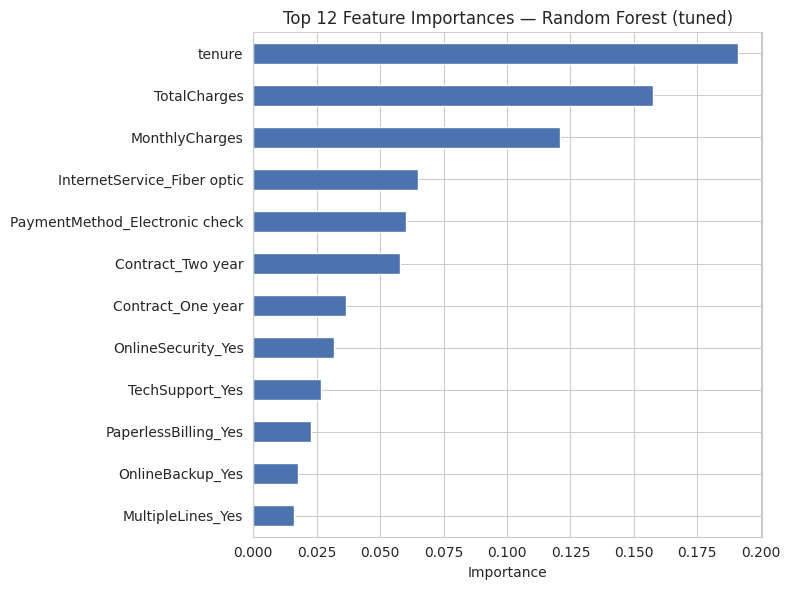

tenure                            0.191132
TotalCharges                      0.157462
MonthlyCharges                    0.120849
InternetService_Fiber optic       0.064952
PaymentMethod_Electronic check    0.060395
Contract_Two year                 0.057835
Contract_One year                 0.036472
OnlineSecurity_Yes                0.031953
TechSupport_Yes                   0.026817
PaperlessBilling_Yes              0.022845
dtype: float64

In [12]:
FINAL_MODEL = tuned_rf
FINAL_MODEL_NAME = 'Random Forest (tuned)'

importances = pd.Series(FINAL_MODEL.feature_importances_, index=X.columns).sort_values(ascending=False)

top_n = 12
plt.figure(figsize=(8, 6))
importances.head(top_n).sort_values().plot(kind='barh', color='#4C72B0')
plt.title(f'Top {top_n} Feature Importances — {FINAL_MODEL_NAME}')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

importances.head(10)

**Task 15 — Which features matter most?**

The top features are **`tenure`** (0.191), **`TotalCharges`** (0.157), **`MonthlyCharges`** (0.121),
**`InternetService_Fiber optic`** (0.065), and **`PaymentMethod_Electronic check`** (0.060) — together these five
account for roughly 60% of the model's total feature importance. This agrees strongly with what Lab 2's EDA and
Lab 3's Decision Tree already pointed to: short-tenure customers on higher charges are the ones most likely to
churn, and Fiber-optic internet plus electronic-check billing showed up as churn-associated segments back in the
EDA too. Seeing the same handful of features rise to the top in a completely different model family (an ensemble
vs. a single tree) is a good sanity check that these are genuine churn drivers in the data, not an artifact of one
model's particular splits.

## 9. Final Model Selection

**Task 14 — Final model and justification**

I'm selecting the **tuned Random Forest (`n_estimators=200`, `max_depth=10`, `min_samples_split=2`)** as the final
model. The justification isn't training score alone — it's the full evidence trail built up across this lab:
it has the best cross-validated F1 of the three candidates (0.571 vs. 0.567 for the Decision Tree and 0.558 for the
default Random Forest, Part 4/5), and on the held-out test set it posts the best F1 (0.595), the best recall
(54.0%) and the best accuracy (80.5%) of all three, losing only narrowly to the Decision Tree on precision (66.2%
vs. 66.7%). Since recall on the churn class is the metric that matters most for this retention use case (Part 3),
and the tuned Random Forest wins there by a real margin (54.0% vs. 49.7%) without sacrificing much precision, it's
the model I'd actually deploy.

## 10. Kaggle Prediction/Submission

Generating predictions on the held-out test set with the final model and assembling a submission-style dataframe.
The cleaned dataset (`clean_churn.csv`) doesn't carry an original `customerID` column — it was dropped during Lab 2
cleaning — so I use each test-set row's original dataframe index as a stand-in customer identifier.

In [13]:
submission = pd.DataFrame({
    'CustomerID': X_test.index,
    'Churn': pd.Series(tuned_test_pred, index=X_test.index).map({0: 'No', 1: 'Yes'})
}).reset_index(drop=True)

submission.to_csv('submission.csv', index=False)
print("Saved submission.csv with", submission.shape[0], "rows.")
submission.head()

Saved submission.csv with 1409 rows.


,CustomerID,Churn
0,437,No
1,2280,Yes
2,2235,No
3,4460,No
4,3761,No


## 11. Conclusion

**Task 17 — Summary**

The final model I chose is the **tuned Random Forest** (`n_estimators=200`, `max_depth=10`,
`min_samples_split=2`), selected through 5-fold cross-validated `GridSearchCV` on F1-score. Compared to the Lab 3
Decision Tree baseline (max_depth=6), it improves test accuracy from 80.1% to 80.5%, and — more importantly for
this problem — recall on the churn class from 49.7% to 54.0%, lifting F1 from 0.570 to 0.595. Its main remaining
limitation is that recall is still only just above half: the model still misses close to 46% of customers who will
actually churn, and its precision (66.2%) means roughly a third of the customers it flags as "at risk" won't
actually leave, which still costs some wasted retention budget. It's a genuine improvement over the single tree,
not a solved problem.

**Task 18 — What I'd try next**

With more time I'd try directly handling the class imbalance rather than relying on the model to work around it —
for example `class_weight='balanced'` in the Random Forest, or oversampling the minority class with SMOTE before
training — since recall on the churn class is still the weakest number in the whole table. I'd also compare against
a gradient-boosted model (e.g. `GradientBoostingClassifier` or XGBoost/LightGBM), which often outperforms a Random
Forest on tabular data like this, and widen the hyperparameter grid (particularly `max_features` and
`min_samples_leaf`) now that I know roughly where the good region of the search space is.